In [27]:
import torch as ch
import torch.nn as nn
from torch.nn import CrossEntropyLoss, MSELoss
from torch.nn import Softmax
import torch.optim as optim

import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

import torch as ch
from torch import sigmoid as sig
from torch.distributions import MultivariateNormal
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np
from sklearn.linear_model import LogisticRegression

from delphi.utils.helpers import logistic
from torch.distributions.gumbel import Gumbel
from delphi.stats.softmax import SoftmaxRegression

In [2]:
gumbel = Gumbel(0, 1)

In [46]:
# ================================================================
# 1. Custom Truncated Cross Entropy Function
#    (demo version: untruncated BCE + small deterministic smoothing)
# ================================================================

noise = gumbel.sample([])

class TruncatedCE(ch.autograd.Function):
    @staticmethod
    def forward(ctx, pred, targ, phi, eps=1e-5):
        """
        Args: 
            pred (torch.Tensor): size (batch_size, 1) matrix for regression model predictions
            targ (torch.Tensor): size (batch_size, 1) matrix for regression target predictions
            phi (oracle.oracle): dependent variable membership oracle
            num_samples (int): number of samples to generate per sample in batch in rejection sampling procedure
            eps (float): denominator error constant to avoid divide by zero errors
        """     
        stacked = pred[None, ...].repeat(NUM_SAMPLES, 1, 1)
#         rand_noise = gumbel.sample(stacked.size())a
#         import pdb; pdb.set_trace()
        noised = stacked + NOISE
        noised_labs = noised.argmax(-1, keepdim=True)
        filtered = phi(noised).float()
        mask = (noised_labs).eq(targ)
        ctx.save_for_backward(mask, filtered, NOISE, pred)
        ctx.eps = eps
        prob_est = (mask * filtered + eps).sum(0) / (filtered.sum(0) + eps)
        return -ch.log(prob_est) / pred.size(0)
        
    @staticmethod
    def backward(ctx, grad_output):  
        mask, filtered, rand_noise, pred = ctx.saved_tensors
        inner_exp = (1 - ch.exp(-rand_noise))
        nll = ((inner_exp * mask * filtered).sum(0) / ((mask * filtered).sum(0) + ctx.eps))
#         nll = ((inner_exp * mask * filtered).sum(0) / ((mask * filtered).sum(0) + ctx.eps))

        const = ((inner_exp * filtered).sum(0) / (filtered.sum(0) + ctx.eps))
#         const = ((inner_exp * filtered).sum(0) / (filtered.sum(0) + ctx.eps))

        return (-nll + const) / pred.size(0), None, None, None, None


def truncated_ce_loss(logits, targets):
    return TruncatedCE.apply(logits, targets, phi)

import math
samples  = ch.randn(10000, 1)
class TruncatedMSE(ch.autograd.Function):
    @staticmethod
    def forward(ctx, pred, targ, phi, noise_var, num_samples=10000, eps=1e-5):
        N = pred.shape[0]

        # Sample latent points
        stacked = pred.unsqueeze(1).repeat(1, num_samples, 1)
        noise = (noise_var ** 0.5) * samples.repeat(pred.size(0), 1, 1) 

        # noise = (noise_var ** 0.5) * ch.randn_like(stacked)
        noised = stacked + noise

        # Apply truncation
        mask = phi(noised).float()

        # Conditional mean E[Y | Y ∈ S]
        z_num = (mask * noised).sum(dim=1)
        z_den = mask.sum(dim=1) + eps
        z = z_num / z_den  # (N, 1)

        # Probability mass P(Y in S)
        P_hat = mask.mean(dim=1)  # (N, 1)

        # Save for backward
        ctx.save_for_backward(pred, targ, noised, mask, P_hat, z, noise_var)

        # Compute log-likelihood
        quadratic_loss = -0.5 * (targ - pred).pow(2)
        log_integral = ch.log(math.sqrt(2 * math.pi * noise_var) * P_hat + eps)

        return (log_integral - quadratic_loss) / pred.size(0)

    @staticmethod
    def backward(ctx, grad_output):
        pred, targ, noised, mask, P_hat, z, noise_var = ctx.saved_tensors
        eps = 1e-8

        # Mean-centered samples
        centered = noised 

        # Monte Carlo estimate of E[(z - pred) phi(z)]
        correction_term = (mask * centered).mean(dim=1) / (P_hat + eps)

        # Gradient wrt pred
        grad_pred = (targ - correction_term) / noise_var

        # Multiply by grad_output (from upstream)
        grad_pred = grad_pred 

        return - grad_pred / pred.size(0), None, None, None, None, None
    
def truncated_mse(logits, targets): 
    return TruncatedMSE.apply(logits, targets, phi, ch.ones(1,1))

In [32]:
# ================================================================
# 2. Simple model: logistic regression
# ================================================================

class LinearModel(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.w = nn.Parameter(ch.rand(dim, 1))
        self.b = nn.Parameter(ch.rand(1))

    def forward(self, x):
        return x @ self.w + self.b

In [33]:
softmax = Softmax()

In [71]:
# ================================================================
# 3. Synthetic data
# ================================================================

ch.manual_seed(0)

N = 500
D = 5
NUM_SAMPLES = 5000
X = ch.randn(N, D)
true_w = ch.randn(D, 1)
true_b = ch.randn(1)

y = X @ true_w + true_b + ch.randn(N, 1)


In [72]:
# ================================================================
# 4. Build model + LBFGS optimizer
# ================================================================

model = LinearModel(D)

optimizer = optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=20,
    history_size=50,
    line_search_fn="strong_wolfe", 
)

In [73]:
def phi(z): 
    return ch.ones_like(z)

def phi(z): 
    return z > 0

NOISE = gumbel.sample([NUM_SAMPLES, N, 2]).detach()

ce = CrossEntropyLoss()
l2 = 5e-4

In [74]:
trunc_indices = phi(y).flatten().nonzero().flatten()
X_trunc, Y_trunc = X[trunc_indices], y[trunc_indices]

alpha = phi(y).sum() / y.size(0)
print(f'alpha: {alpha}')

alpha: 0.3019999861717224


In [75]:
from torch.nn import BCEWithLogitsLoss

bce_loss = BCEWithLogitsLoss()

mse_loss = MSELoss()

In [76]:
# ================================================================
# 5. L-BFGS training loop with closure
# ================================================================

def closure():
    optimizer.zero_grad()

    logits = model(X_trunc)
    loss = truncated_mse(logits, Y_trunc).sum()
    loss.backward()
    
    return loss

for epoch in range(30):
    loss = optimizer.step(closure)
    print(f"Epoch {epoch:03d} | Loss = {loss.item():.6f}")


# ================================================================
# 6. Compare learned parameters to true ones
# ================================================================

print("\nTrue w:", true_w.view(-1).tolist())
print("Learned w:", model.w.view(-1).tolist())

print("\nTrue b:", true_b.tolist())
print("Learned b:", model.b.tolist())

Epoch 000 | Loss = 1.779373
Epoch 001 | Loss = 1.006799
Epoch 002 | Loss = 1.006799
Epoch 003 | Loss = 1.006799
Epoch 004 | Loss = 1.006799
Epoch 005 | Loss = 1.006799
Epoch 006 | Loss = 1.006799
Epoch 007 | Loss = 1.006799
Epoch 008 | Loss = 1.006799
Epoch 009 | Loss = 1.006799
Epoch 010 | Loss = 1.006799
Epoch 011 | Loss = 1.006799
Epoch 012 | Loss = 1.006799
Epoch 013 | Loss = 1.006799
Epoch 014 | Loss = 1.006799
Epoch 015 | Loss = 1.006799
Epoch 016 | Loss = 1.006799
Epoch 017 | Loss = 1.006799
Epoch 018 | Loss = 1.006799
Epoch 019 | Loss = 1.006799
Epoch 020 | Loss = 1.006799
Epoch 021 | Loss = 1.006799
Epoch 022 | Loss = 1.006799
Epoch 023 | Loss = 1.006799
Epoch 024 | Loss = 1.006799
Epoch 025 | Loss = 1.006799
Epoch 026 | Loss = 1.006799
Epoch 027 | Loss = 1.006799
Epoch 028 | Loss = 1.006799
Epoch 029 | Loss = 1.006799

True w: [0.40286168456077576, -1.4230061769485474, 0.48716601729393005, 1.6725716590881348, 0.7534995675086975]
Learned w: [0.3558131456375122, -1.232607007026

In [108]:
y.long()

tensor([[1],
        [1],
        [1],
        [1],
        [0],
        [1],
        [0],
        [1],
        [1],
        [0],
        [1],
        [1],
        [0],
        [1],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0],
        [1],
        [0],
        [1],
        [1],
        [1],
        [0],
        [1],
        [0],
        [1],
        [0],
        [1],
        [1],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0],
        [0],
        [1],
        [1],
        [1],
        [1],
        [0],
        [1],
        [1],
        [0],
        [1],
        [1],
        [0],
        [1],
        [0],
        [0],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [0],
        [1],

<IPython.core.display.Javascript object>


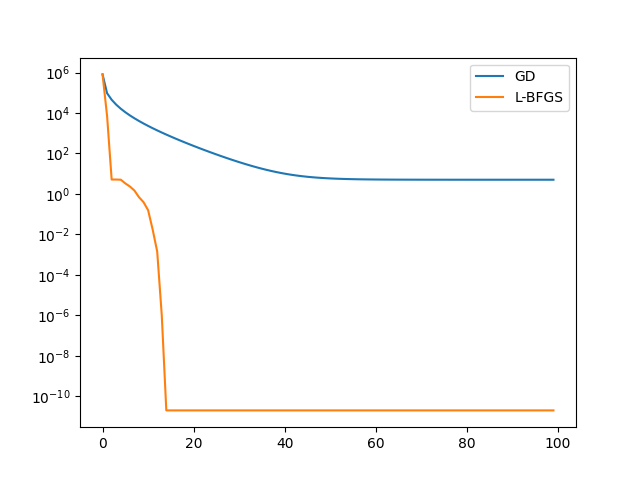

In [14]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt


# 2d Rosenbrock function
def f(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2


# Gradient descent
x_gd = 10*torch.ones(2, 1)
x_gd.requires_grad = True
gd = optim.SGD([x_gd], lr=1e-5)
history_gd = []
for i in range(100):
    gd.zero_grad()
    objective = f(x_gd)
    objective.backward()
    gd.step()
    history_gd.append(objective.item())


# L-BFGS
def closure():
    lbfgs.zero_grad()
    objective = f(x_lbfgs)
    objective.backward()
    return objective

x_lbfgs = 10*torch.ones(2, 1)
x_lbfgs.requires_grad = True

lbfgs = optim.LBFGS([x_lbfgs],
                    history_size=10, 
                    max_iter=4, 
                    line_search_fn="strong_wolfe")
                    
history_lbfgs = []
for i in range(100):
    history_lbfgs.append(f(x_lbfgs).item())
    lbfgs.step(closure)


# Plotting
plt.semilogy(history_gd, label='GD')
plt.semilogy(history_lbfgs, label='L-BFGS')
plt.legend()
plt.show()